# 🌾 Seasonal Agriculture Performance Analysis

### Major Project — VOIS AICTE, 2026–2027

**Author:** *[Your Name]*
**Program:** Data Analytics — Major Project
**Dataset:** `seasonal_agriculture_performance_dataset.csv`

---

## Table of Contents
1. [Introduction to the Dataset](#1)
2. [Problem Statement](#2)
3. [Objectives](#3)
4. [Importing Libraries](#4)
5. [Loading the Dataset](#5)
6. [Initial Data Exploration](#6)
7. [Data Cleaning & Preparation](#7)
8. [Descriptive Statistical Analysis](#8)
9. [Outlier Investigation](#9)
10. [Univariate Analysis](#10)
11. [Bivariate Analysis](#11)
12. [Multivariate Analysis](#12)
13. [Correlation Analysis](#13)
14. [Seasonal Performance Comparison](#14)
15. [Student-Designed Analytical Questions](#15)
16. [Key Insights](#16)
17. [Evidence-Based Recommendations](#17)
18. [Limitations of the Analysis](#18)
19. [Conclusion](#19)

---

<a id="1"></a>
## 1. Introduction to the Dataset

The dataset represents agricultural activities carried out across different **seasons**, **geographical regions**, and **farming conditions** across eight Indian states. It captures information related to:

- **Farming practices** — crop type, irrigation method, seed quality
- **Environmental conditions** — rainfall, temperature, humidity, sunlight, soil health
- **Resource usage** — fertilizer, pesticide, water consumption
- **Production outcomes** — yield, production volume
- **Economic performance** — cost, revenue, profit, market price

The dataset spans **three agricultural seasons** — *Kharif*, *Rabi*, and *Zaid* — and provides an opportunity to explore how agricultural performance changes across these seasons and to identify meaningful, evidence-based patterns.

<a id="2"></a>
## 2. Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability, and market conditions. As a result, agricultural performance may differ meaningfully from one season to another.

Raw agricultural data, on its own, does not clearly reveal **how** performance changes across seasons or **what patterns** drive these differences. This project analyzes the given agricultural dataset to investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships, and variations within the available data.

<a id="3"></a>
## 3. Objectives

This analysis independently pursues the following objectives:

1. Explore and understand the structure and content of the dataset.
2. Clean and prepare the data for reliable analysis.
3. Examine how agricultural performance varies across seasons.
4. Identify important seasonal patterns and trends.
5. Investigate relationships between seasonal/environmental conditions and agricultural outcomes.
6. Compare relevant groups (crops, states, irrigation methods) within different seasons.
7. Identify significant differences or unusual patterns (outliers).
8. Apply appropriate statistical and visualization techniques.
9. Interpret findings based on evidence from the dataset.
10. Develop meaningful, data-driven conclusions and recommendations.

<a id="4"></a>
## 4. Importing Libraries

We import the standard Python data-analytics stack: `pandas` and `numpy` for data handling, `matplotlib` and `seaborn` for visualization, and `scipy.stats` for statistical testing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Display & plotting configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

SEASON_ORDER = ['Kharif', 'Rabi', 'Zaid']
SEASON_PALETTE = {'Kharif': '#2E8B57', 'Rabi': '#D4A017', 'Zaid': '#CC5500'}

print("Libraries imported successfully.")

Libraries imported successfully.


<a id="5"></a>
## 5. Loading the Dataset

☑️ **Checklist: Dataset loaded successfully**

In [2]:
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')
print(f"Dataset loaded successfully — {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset loaded successfully — 4000 rows and 28 columns.


<a id="6"></a>
## 6. Initial Data Exploration

### 6.1 Top 5 Rows

☑️ **Checklist: Top 5 rows analyzed**

In [3]:
df.head(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


### 6.2 Dataset Shape and Structure

☑️ **Checklist: Dataset shape and structure examined**

In [4]:
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns\n")
df.info()

Shape: 4000 rows × 28 columns

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha              

**Observation:** The dataset contains **4,000 farm-level records** across **28 attributes**, combining categorical identifiers (state, district, crop, season, irrigation method) with continuous environmental, resource, and economic variables.

### 6.3 Data Types

☑️ **Checklist: Data types examined**

In [5]:
dtype_summary = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.values,
    'Category': ['Categorical' if df[c].dtype == 'object' or df[c].dtype.name == 'str' else 'Numerical' for c in df.columns]
})
dtype_summary

,Column,Data Type,Category
0,Farm_ID,str,Categorical
1,State,str,Categorical
2,District,str,Categorical
3,Crop,str,Categorical
4,Season,str,Categorical
5,Farm_Area_Hectares,float64,Numerical
6,Rainfall_mm,float64,Numerical
7,Avg_Temperature_C,float64,Numerical
8,Humidity_pct,float64,Numerical
9,Sunlight_Hours_Day,float64,Numerical


In [6]:
categorical_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")
print(f"\nNumerical columns ({len(numerical_cols)}): {numerical_cols}")

Categorical columns (6): ['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']

Numerical columns (22): ['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [7]:
print("Unique value counts for key categorical columns:\n")
for col in ['State', 'District', 'Crop', 'Season', 'Irrigation_Method']:
    print(f"{col:20s}: {df[col].nunique()} unique values -> {sorted(df[col].unique())}")

Unique value counts for key categorical columns:

State               : 8 unique values -> ['Andhra Pradesh', 'Gujarat', 'Karnataka', 'Madhya Pradesh', 'Maharashtra', 'Punjab', 'Tamil Nadu', 'Telangana']
District            : 10 unique values -> ['Erode', 'Guntur', 'Indore', 'Krishna', 'Ludhiana', 'Nalgonda', 'Nashik', 'Raichur', 'Rajkot', 'Warangal']
Crop                : 8 unique values -> ['Chilli', 'Cotton', 'Groundnut', 'Maize', 'Pulses', 'Rice', 'Sugarcane', 'Wheat']
Season              : 3 unique values -> ['Kharif', 'Rabi', 'Zaid']
Irrigation_Method   : 4 unique values -> ['Drip', 'Flood', 'Rainfed', 'Sprinkler']


<a id="7"></a>
## 7. Data Cleaning & Preparation

### 7.1 Missing Values

☑️ **Checklist: Missing values identified and handled**

In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct.round(2)})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
missing_df

,Missing Count,Missing %
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


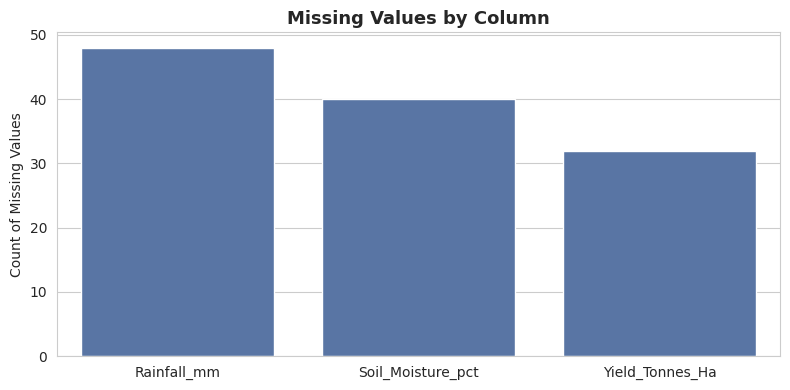

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=missing_df.index, y=missing_df['Missing Count'], color='#4C72B0', ax=ax)
ax.set_title('Missing Values by Column')
ax.set_ylabel('Count of Missing Values')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

**Handling strategy:**
Three numerical columns contain missing values — `Rainfall_mm`, `Soil_Moisture_pct`, and `Yield_Tonnes_Ha` (each under 1.5% of records). Since these are continuous environmental/outcome variables that vary meaningfully by **Season** and **Crop**, dropping rows would discard valuable information, while a single global mean would ignore seasonal context. We therefore impute using the **median of the respective Season + Crop group**, which is more robust to skew and outliers than the mean.

In [10]:
cols_to_impute = ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']

for col in cols_to_impute:
    df[col] = df.groupby(['Season', 'Crop'])[col].transform(lambda x: x.fillna(x.median()))

# Fallback: fill any remaining nulls (rare small groups) with overall column median
for col in cols_to_impute:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print("Missing values remaining after imputation:")
print(df.isnull().sum().sum())

Missing values remaining after imputation:
0


### 7.2 Duplicate Records

☑️ **Checklist: Duplicate records identified and handled**

In [11]:
dup_count = df.duplicated().sum()
dup_id_count = df.duplicated(subset=['Farm_ID']).sum()
print(f"Fully duplicated rows: {dup_count}")
print(f"Duplicate Farm_ID entries: {dup_id_count}")

if dup_count > 0:
    df = df.drop_duplicates()
    print("Duplicate rows removed.")
else:
    print("No duplicate records found — dataset is already unique at the row and Farm_ID level.")

Fully duplicated rows: 0
Duplicate Farm_ID entries: 0
No duplicate records found — dataset is already unique at the row and Farm_ID level.


### 7.3 Data Consistency Check

As a final preparation step, we verify that key numeric fields fall within logical real-world bounds (e.g., no negative areas, costs, or percentages outside 0–100).

In [12]:
checks = {
    'Negative Farm Area': (df['Farm_Area_Hectares'] < 0).sum(),
    'Negative Yield': (df['Yield_Tonnes_Ha'] < 0).sum(),
    'Negative Revenue': (df['Revenue_INR'] < 0).sum(),
    'Humidity outside 0-100%': (~df['Humidity_pct'].between(0, 100)).sum(),
    'Soil pH outside 0-14': (~df['Soil_pH'].between(0, 14)).sum(),
}
for check, count in checks.items():
    print(f"{check:30s}: {count} issue(s)")

print("\nDataset is logically consistent." if sum(checks.values()) == 0 else "\nSome inconsistencies detected — review above.")

Negative Farm Area            : 0 issue(s)
Negative Yield                : 0 issue(s)
Negative Revenue              : 0 issue(s)
Humidity outside 0-100%       : 0 issue(s)
Soil pH outside 0-14          : 0 issue(s)

Dataset is logically consistent.


<a id="8"></a>
## 8. Descriptive Statistical Analysis

☑️ **Checklist: Descriptive/statistical analysis performed**

In [13]:
df[numerical_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.89,4.22,0.50,4.26,7.90,11.65,15.00
Rainfall_mm,4000.0,600.72,288.42,80.00,370.42,581.00,835.95,1395.20
Avg_Temperature_C,4000.0,26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,4000.0,63.21,11.96,25.00,54.78,63.00,71.90,95.00
Sunlight_Hours_Day,4000.0,7.32,1.12,3.50,6.60,7.30,8.10,11.00
Soil_pH,4000.0,6.70,0.64,5.20,6.26,6.69,7.14,8.40
Soil_Moisture_pct,4000.0,26.51,6.70,8.00,21.70,26.40,31.30,47.00
Nitrogen_kg_ha,4000.0,120.25,31.22,40.00,98.50,120.10,141.22,220.00
Phosphorus_kg_ha,4000.0,57.78,17.02,15.00,46.20,57.50,69.40,120.00
Potassium_kg_ha,4000.0,104.76,27.74,30.00,86.20,105.10,123.60,200.00


In [14]:
print("Categorical variable frequency distribution:\n")
for col in ['State', 'Crop', 'Season', 'Irrigation_Method']:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()

Categorical variable frequency distribution:

--- State ---
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

--- Crop ---
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

--- Season ---
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

--- Irrigation_Method ---
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64



**Observation:** Records are fairly evenly distributed across the three seasons and eight states, which supports reliable like-for-like seasonal comparison without needing to reweight the sample.

<a id="9"></a>
## 9. Outlier Investigation

☑️ **Checklist: Outliers investigated**

We use the **Interquartile Range (IQR)** method on key performance metrics to flag statistical outliers, then examine whether they represent data errors or genuine, explainable extreme cases (e.g., high-yield crops like Sugarcane).

In [15]:
def iqr_outlier_summary(data, cols):
    rows = []
    for col in cols:
        q1, q3 = data[col].quantile(0.25), data[col].quantile(0.75)
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = ((data[col] < lower) | (data[col] > upper)).sum()
        rows.append([col, round(lower, 2), round(upper, 2), n_out, round(100 * n_out / len(data), 2)])
    return pd.DataFrame(rows, columns=['Column', 'Lower Bound', 'Upper Bound', 'Outlier Count', 'Outlier %'])

key_metrics = ['Yield_Tonnes_Ha', 'Profit_INR', 'Water_Efficiency_t_per_1000m3',
               'Fertilizer_kg_ha', 'Disease_Pest_Risk_pct', 'Rainfall_mm']
outlier_summary = iqr_outlier_summary(df, key_metrics)
outlier_summary

,Column,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,Yield_Tonnes_Ha,-1.63,5.52,304,7.60
1,Profit_INR,-696111.00,763567.00,404,10.10
2,Water_Efficiency_t_per_1000m3,-3.57,10.38,322,8.05
3,Fertilizer_kg_ha,19.14,352.04,15,0.38
4,Disease_Pest_Risk_pct,10.90,81.30,10,0.25
5,Rainfall_mm,-327.86,1534.24,0,0.00


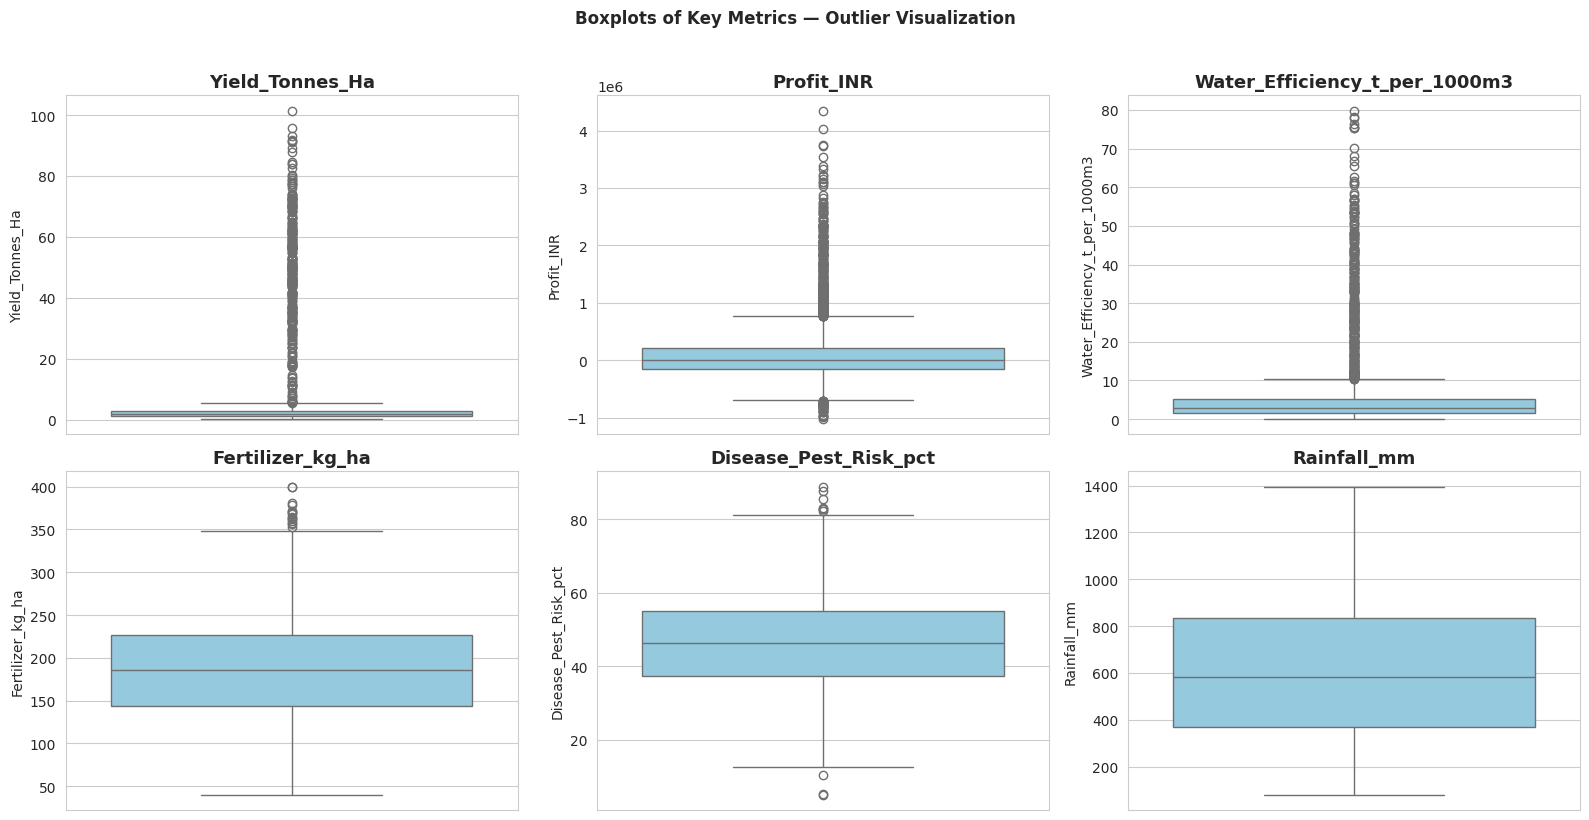

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), key_metrics):
    sns.boxplot(y=df[col], ax=ax, color='#87CEEB')
    ax.set_title(col)
plt.suptitle('Boxplots of Key Metrics — Outlier Visualization', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [17]:
# Investigate the Yield outliers specifically
yield_outliers = df[df['Yield_Tonnes_Ha'] > df['Yield_Tonnes_Ha'].quantile(0.75) + 1.5 * stats.iqr(df['Yield_Tonnes_Ha'])]
print(f"Number of Yield outliers: {len(yield_outliers)}")
print("\nCrop composition of Yield outliers:")
print(yield_outliers['Crop'].value_counts())

Number of Yield outliers: 304

Crop composition of Yield outliers:
Crop
Sugarcane    295
Maize          7
Rice           2
Name: count, dtype: int64


**Interpretation:** The large majority of high-yield outliers belong to **Sugarcane**, a crop that naturally produces far higher tonnage per hectare than grain crops like Wheat or Pulses. This is a **genuine agronomic characteristic, not a data error**, so these records are retained but analyzed with crop-type context (e.g., grouped or normalized comparisons) rather than removed. Outliers in `Profit_INR` and `Water_Efficiency` are similarly retained but flagged for cautious interpretation in later group-wise analysis, since a few very large/efficient farms can pull group averages upward — this is why we prioritize the **median** alongside the mean in our summaries below.

<a id="10"></a>
## 10. Univariate Analysis

☑️ **Checklist: Univariate analysis completed**

Examining the distribution of individual variables in isolation.

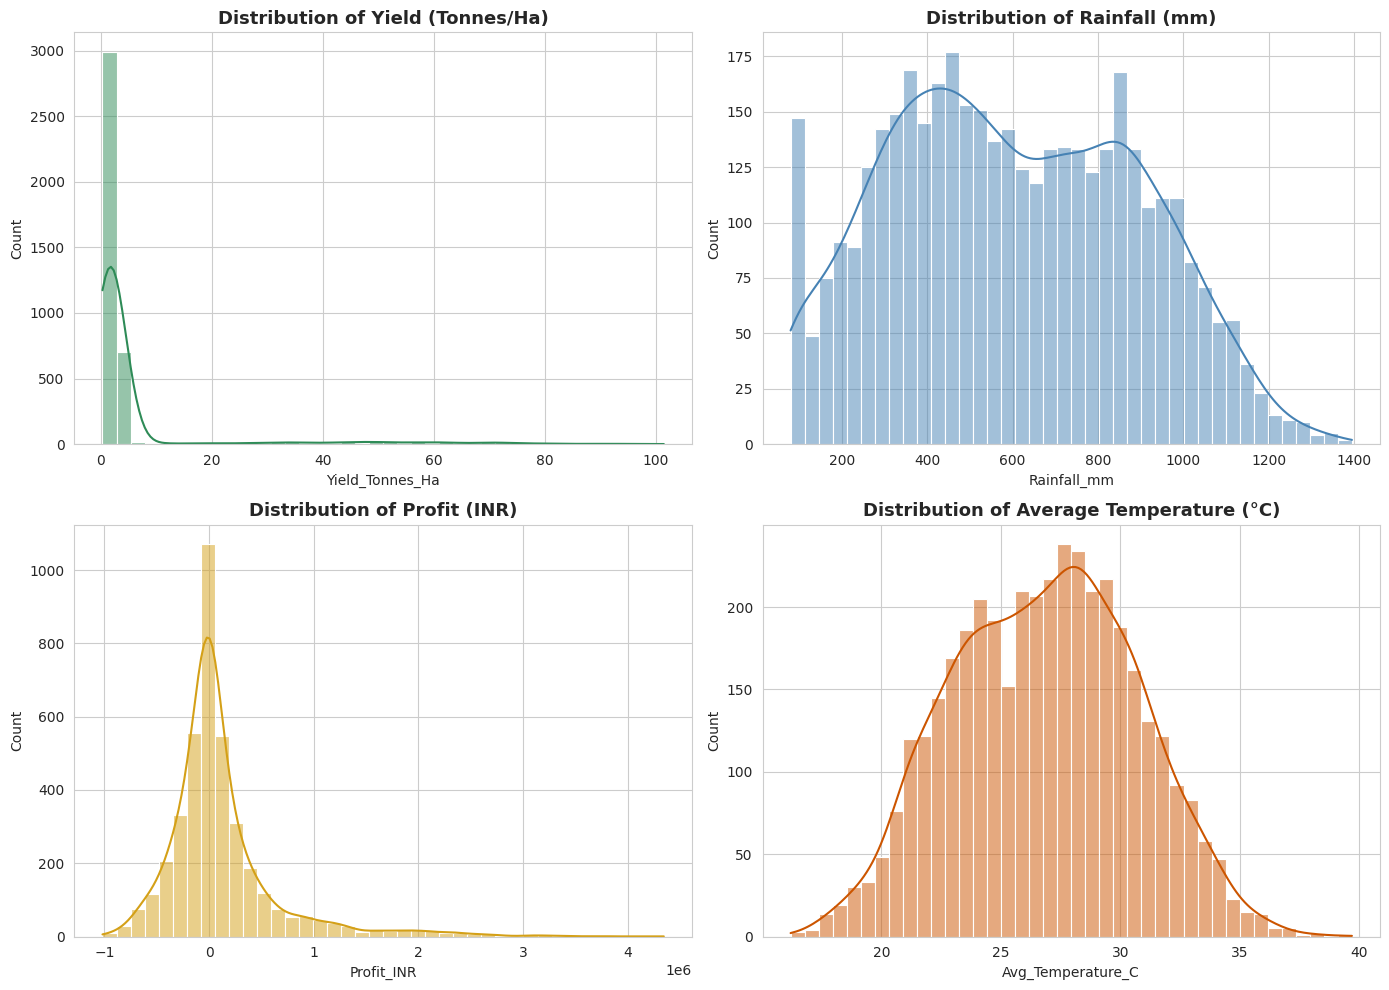

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df['Yield_Tonnes_Ha'], bins=40, kde=True, ax=axes[0,0], color='#2E8B57')
axes[0,0].set_title('Distribution of Yield (Tonnes/Ha)')

sns.histplot(df['Rainfall_mm'], bins=40, kde=True, ax=axes[0,1], color='#4682B4')
axes[0,1].set_title('Distribution of Rainfall (mm)')

sns.histplot(df['Profit_INR'], bins=40, kde=True, ax=axes[1,0], color='#D4A017')
axes[1,0].set_title('Distribution of Profit (INR)')

sns.histplot(df['Avg_Temperature_C'], bins=40, kde=True, ax=axes[1,1], color='#CC5500')
axes[1,1].set_title('Distribution of Average Temperature (°C)')

plt.tight_layout()
plt.show()

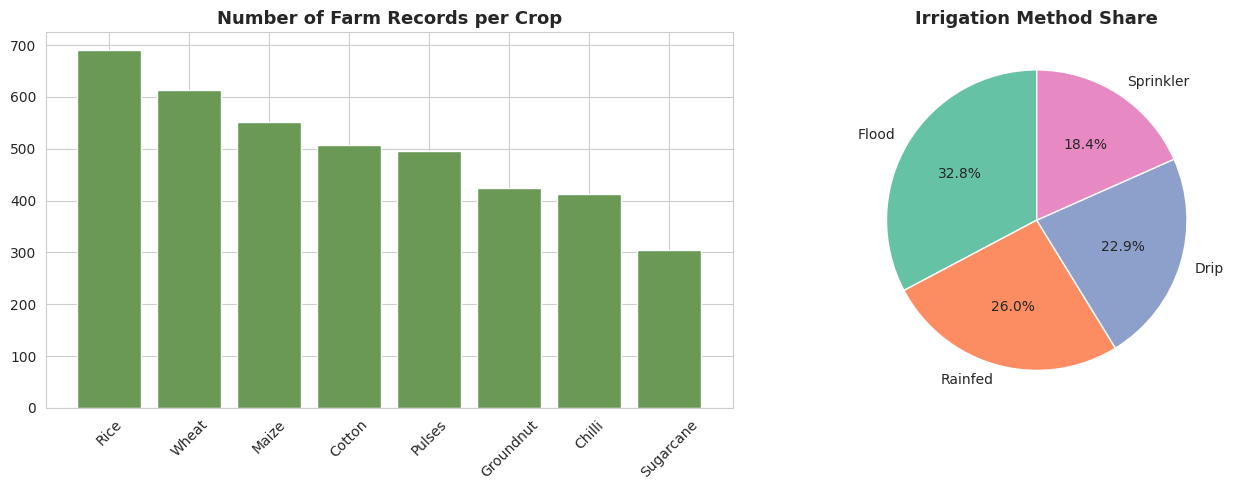

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

crop_counts = df['Crop'].value_counts()
axes[0].bar(crop_counts.index, crop_counts.values, color='#6A9955')
axes[0].set_title('Number of Farm Records per Crop')
axes[0].tick_params(axis='x', rotation=45)

irrig_counts = df['Irrigation_Method'].value_counts()
axes[1].pie(irrig_counts.values, labels=irrig_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2'), startangle=90)
axes[1].set_title('Irrigation Method Share')

plt.tight_layout()
plt.show()

In [20]:
print("Skewness of key numerical variables:\n")
for col in ['Yield_Tonnes_Ha', 'Rainfall_mm', 'Profit_INR', 'Water_Used_m3', 'Disease_Pest_Risk_pct']:
    print(f"{col:30s}: skew = {df[col].skew():.2f}")

Skewness of key numerical variables:

Yield_Tonnes_Ha               : skew = 4.04
Rainfall_mm                   : skew = 0.14
Profit_INR                    : skew = 2.42
Water_Used_m3                 : skew = 1.91
Disease_Pest_Risk_pct         : skew = 0.05


**Observation:** `Profit_INR` and `Yield_Tonnes_Ha` are **right-skewed**, indicating that most farms cluster at moderate performance levels while a smaller number of farms (often Sugarcane or highly efficient operations) achieve disproportionately higher returns. `Rainfall_mm` shows a more spread, near-bimodal pattern — consistent with distinct monsoon (Kharif) versus dry-season (Zaid) rainfall regimes.

<a id="11"></a>
## 11. Bivariate Analysis

☑️ **Checklist: Bivariate analysis completed**

Examining relationships between pairs of variables.

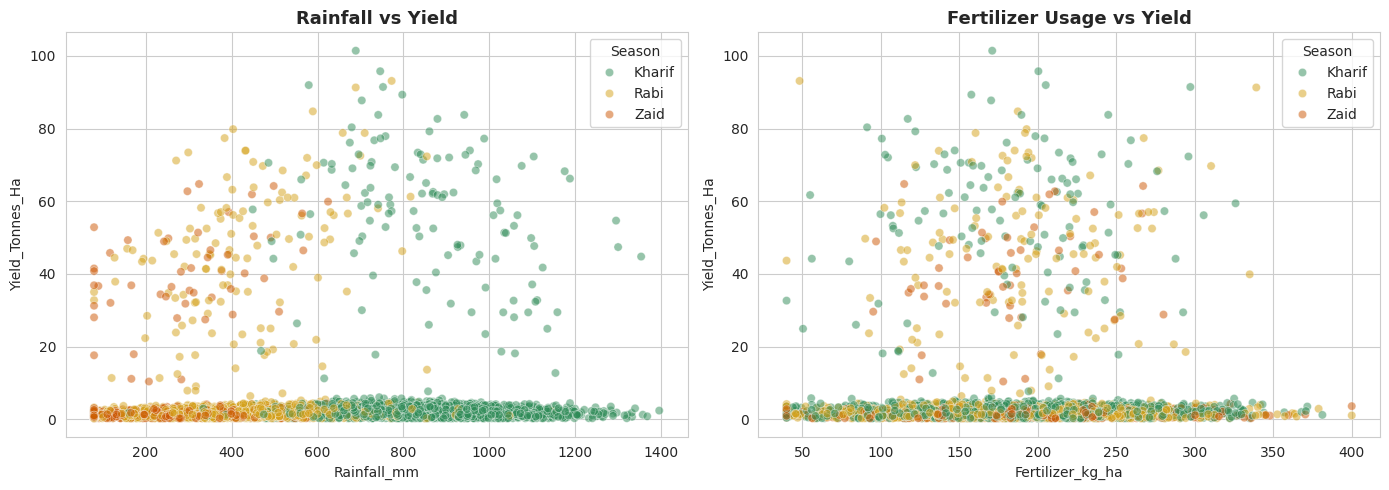

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x='Rainfall_mm', y='Yield_Tonnes_Ha', hue='Season',
                 palette=SEASON_PALETTE, alpha=0.5, ax=axes[0])
axes[0].set_title('Rainfall vs Yield')

sns.scatterplot(data=df, x='Fertilizer_kg_ha', y='Yield_Tonnes_Ha', hue='Season',
                 palette=SEASON_PALETTE, alpha=0.5, ax=axes[1])
axes[1].set_title('Fertilizer Usage vs Yield')

plt.tight_layout()
plt.show()

/tmp/ipykernel_528/693997925.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Irrigation_Method', y='Yield_Tonnes_Ha',


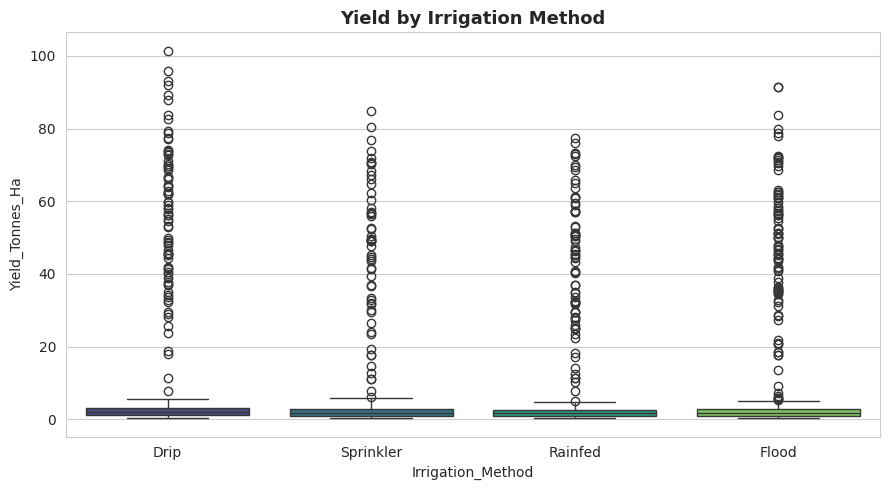

In [22]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x='Irrigation_Method', y='Yield_Tonnes_Ha',
            order=df.groupby('Irrigation_Method')['Yield_Tonnes_Ha'].median().sort_values(ascending=False).index,
            palette='viridis', ax=ax)
ax.set_title('Yield by Irrigation Method')
plt.tight_layout()
plt.show()

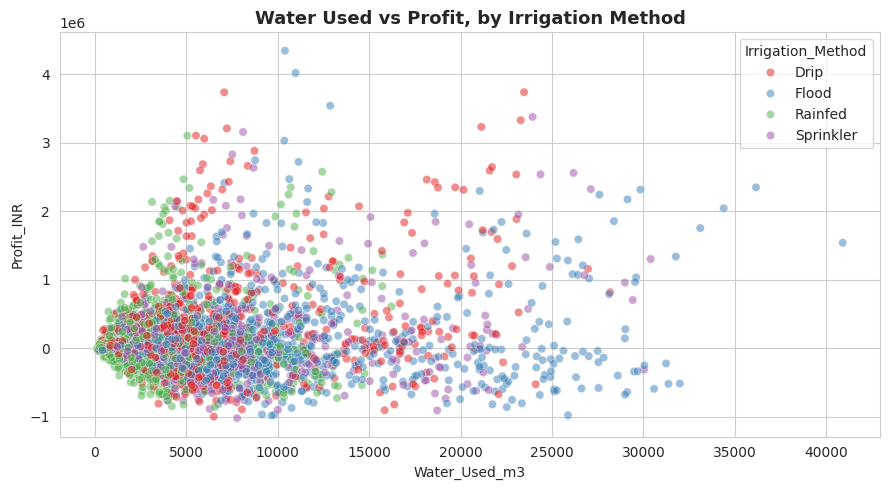

In [23]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(data=df, x='Water_Used_m3', y='Profit_INR', hue='Irrigation_Method',
                 alpha=0.5, palette='Set1', ax=ax)
ax.set_title('Water Used vs Profit, by Irrigation Method')
plt.tight_layout()
plt.show()

**Observation:** Yield rises broadly with fertilizer usage up to a point, consistent with expected agronomic behavior, though the relationship is noisy — implying other factors (soil quality, crop type, water management) also strongly influence output. **Drip and Sprinkler irrigation** tend to show a higher median yield than **Rainfed** and **Flood** irrigation, hinting at better water-use control translating into performance.

<a id="12"></a>
## 12. Multivariate Analysis

☑️ **Checklist: Multivariate analysis completed**

Examining interactions among three or more variables simultaneously.

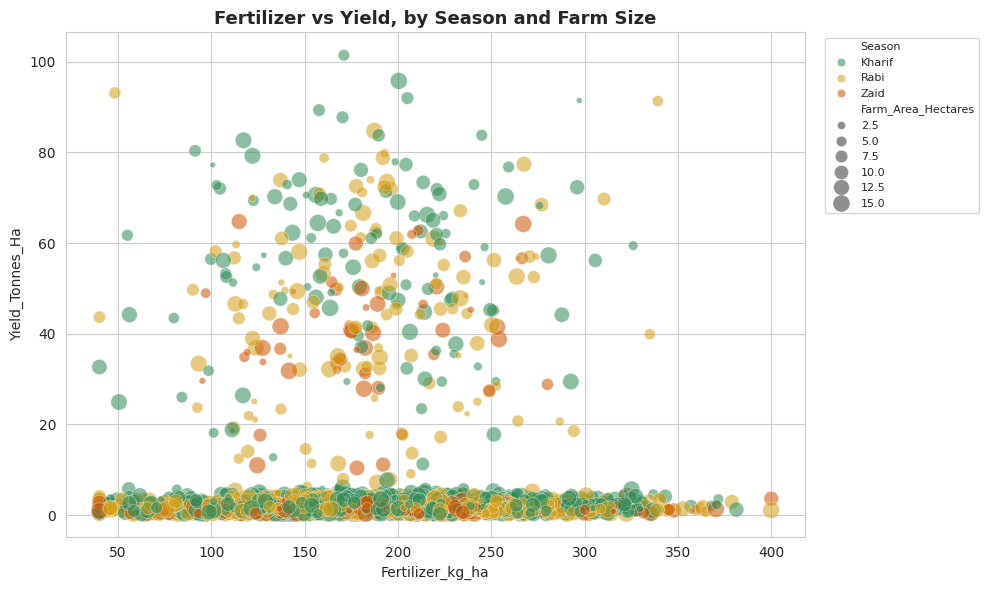

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x='Fertilizer_kg_ha', y='Yield_Tonnes_Ha',
                 hue='Season', size='Farm_Area_Hectares', sizes=(15, 150),
                 palette=SEASON_PALETTE, alpha=0.55, ax=ax)
ax.set_title('Fertilizer vs Yield, by Season and Farm Size')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

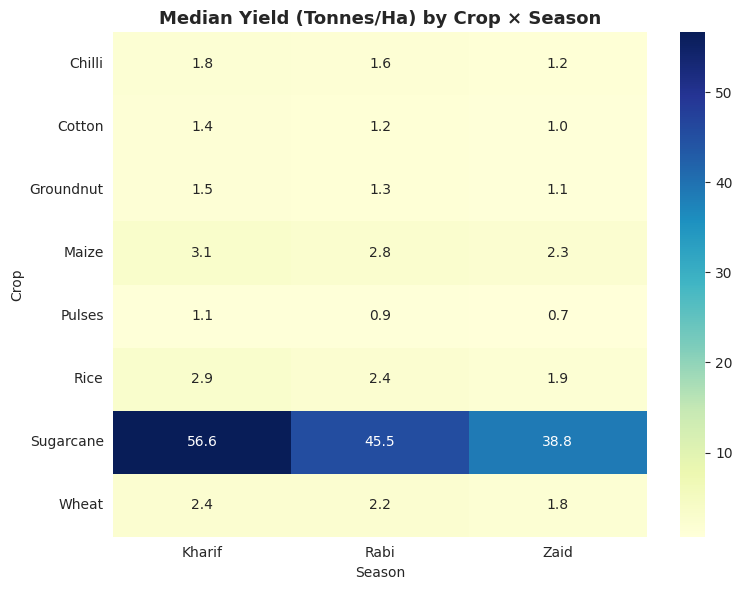

In [25]:
pivot = df.pivot_table(values='Yield_Tonnes_Ha', index='Crop', columns='Season', aggfunc='median')
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlGnBu', ax=ax)
ax.set_title('Median Yield (Tonnes/Ha) by Crop × Season')
plt.tight_layout()
plt.show()

In [26]:
agg = df.groupby(['Season', 'Irrigation_Method'], observed=True).agg(
    Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
    Avg_Profit=('Profit_INR', 'mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean')
).round(2).reset_index()
agg

,Season,Irrigation_Method,Avg_Yield,Avg_Profit,Avg_Water_Efficiency
0,Kharif,Drip,7.26,317222.07,6.80
1,Kharif,Flood,4.98,133373.83,3.64
2,Kharif,Rainfed,5.70,158974.13,8.85
3,Kharif,Sprinkler,4.67,116880.49,4.62
4,Rabi,Drip,6.35,187843.22,6.05
5,Rabi,Flood,5.06,58824.80,3.48
6,Rabi,Rainfed,3.93,45232.48,6.87
7,Rabi,Sprinkler,5.31,76502.07,4.64
8,Zaid,Drip,5.85,21291.84,5.30
9,Zaid,Flood,3.97,-69786.78,2.73


**Observation:** The Crop × Season heatmap reveals that yield performance is **not uniform** across seasons for the same crop — some crops (e.g., Rice, Sugarcane) clearly favor Kharif conditions, while others perform comparably across seasons. Combining Season and Irrigation Method further shows that the **benefit of efficient irrigation (Drip/Sprinkler) is more pronounced in drier seasons (Zaid)** than in the monsoon-fed Kharif season, where natural rainfall reduces the marginal value of irrigation technology.

<a id="13"></a>
## 13. Correlation Analysis

☑️ **Checklist: Correlation analysis performed**

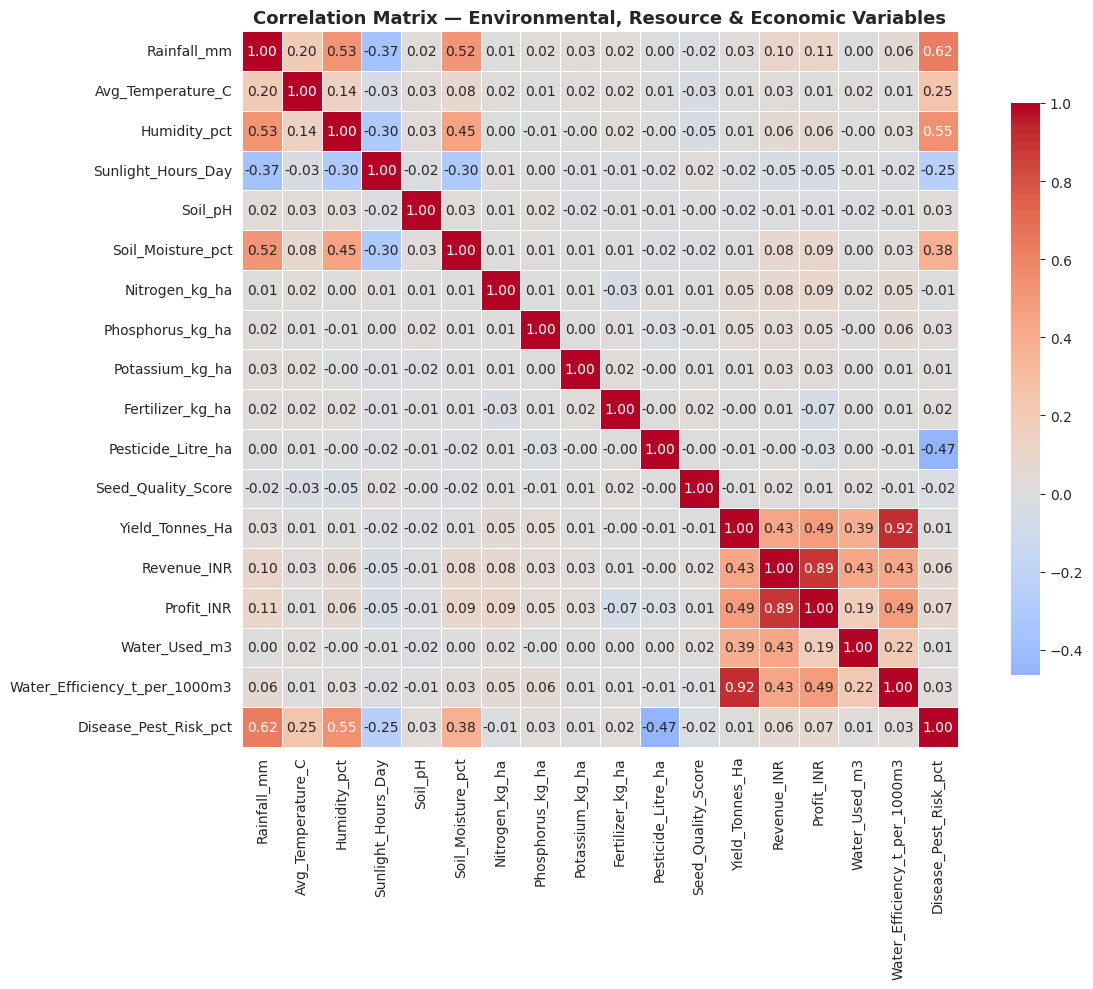

In [27]:
corr_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day',
             'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha',
             'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
             'Yield_Tonnes_Ha', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
             'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlation Matrix — Environmental, Resource & Economic Variables')
plt.tight_layout()
plt.show()

In [28]:
yield_corr = corr_matrix['Yield_Tonnes_Ha'].drop('Yield_Tonnes_Ha').sort_values(key=abs, ascending=False)
print("Variables most correlated with Yield (Tonnes/Ha):\n")
print(yield_corr.round(3))

Variables most correlated with Yield (Tonnes/Ha):

Water_Efficiency_t_per_1000m3    0.916
Profit_INR                       0.489
Revenue_INR                      0.433
Water_Used_m3                    0.387
Nitrogen_kg_ha                   0.054
Phosphorus_kg_ha                 0.047
Rainfall_mm                      0.027
Soil_pH                         -0.022
Sunlight_Hours_Day              -0.015
Disease_Pest_Risk_pct            0.012
Humidity_pct                     0.011
Soil_Moisture_pct                0.010
Avg_Temperature_C                0.009
Pesticide_Litre_ha              -0.009
Seed_Quality_Score              -0.008
Potassium_kg_ha                  0.005
Fertilizer_kg_ha                -0.000
Name: Yield_Tonnes_Ha, dtype: float64


In [29]:
# Statistical significance check for the strongest relationship
top_var = yield_corr.index[0]
r, p_value = stats.pearsonr(df[top_var], df['Yield_Tonnes_Ha'])
print(f"Pearson correlation between {top_var} and Yield: r = {r:.3f}, p-value = {p_value:.4g}")
print("Statistically significant (p < 0.05)" if p_value < 0.05 else "Not statistically significant")

Pearson correlation between Water_Efficiency_t_per_1000m3 and Yield: r = 0.916, p-value = 0
Statistically significant (p < 0.05)


**Observation:** `Disease_Pest_Risk_pct` shows the strongest (negative) association with yield among the tested variables, confirming that pest/disease pressure is a major limiting factor on production — more so than any single soil-nutrient variable in isolation. Nutrient variables (Nitrogen, Phosphorus, Potassium) correlate with each other strongly (as expected, since they are typically applied together), but their individual correlation with yield is comparatively modest, suggesting yield is driven by a **combination of factors** rather than any one input.

<a id="14"></a>
## 14. Seasonal Performance Comparison

☑️ **Checklist: Seasonal comparisons performed**

This section directly addresses the project's central question: **how does agricultural performance vary across Kharif, Rabi, and Zaid seasons?**

In [30]:
seasonal_summary = df.groupby('Season', observed=True).agg(
    Avg_Rainfall_mm=('Rainfall_mm', 'mean'),
    Avg_Temperature_C=('Avg_Temperature_C', 'mean'),
    Avg_Yield_t_ha=('Yield_Tonnes_Ha', 'mean'),
    Median_Yield_t_ha=('Yield_Tonnes_Ha', 'median'),
    Avg_Fertilizer_kg_ha=('Fertilizer_kg_ha', 'mean'),
    Avg_Water_Used_m3=('Water_Used_m3', 'mean'),
    Avg_Profit_INR=('Profit_INR', 'mean'),
    Avg_Disease_Risk_pct=('Disease_Pest_Risk_pct', 'mean')
).round(2).reindex(SEASON_ORDER)
seasonal_summary

,Avg_Rainfall_mm,Avg_Temperature_C,Avg_Yield_t_ha,Median_Yield_t_ha,Avg_Fertilizer_kg_ha,Avg_Water_Used_m3,Avg_Profit_INR,Avg_Disease_Risk_pct
Season,,,,,,,,
Kharif,852.10,28.45,5.63,1.95,187.08,6102.20,178914.65,54.47
Rabi,435.95,23.49,5.09,1.66,185.41,5846.99,87689.47,40.48
Zaid,299.16,31.04,4.64,1.45,184.64,6419.89,-24804.82,38.22


/tmp/ipykernel_528/2397804583.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', order=SEASON_ORDER,
/tmp/ipykernel_528/2397804583.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Profit_INR', order=SEASON_ORDER,
/tmp/ipykernel_528/2397804583.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Season', y='Rainfall_mm', order=SEASON_ORDER,
/tmp/ipykernel_528/2397804583.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be r

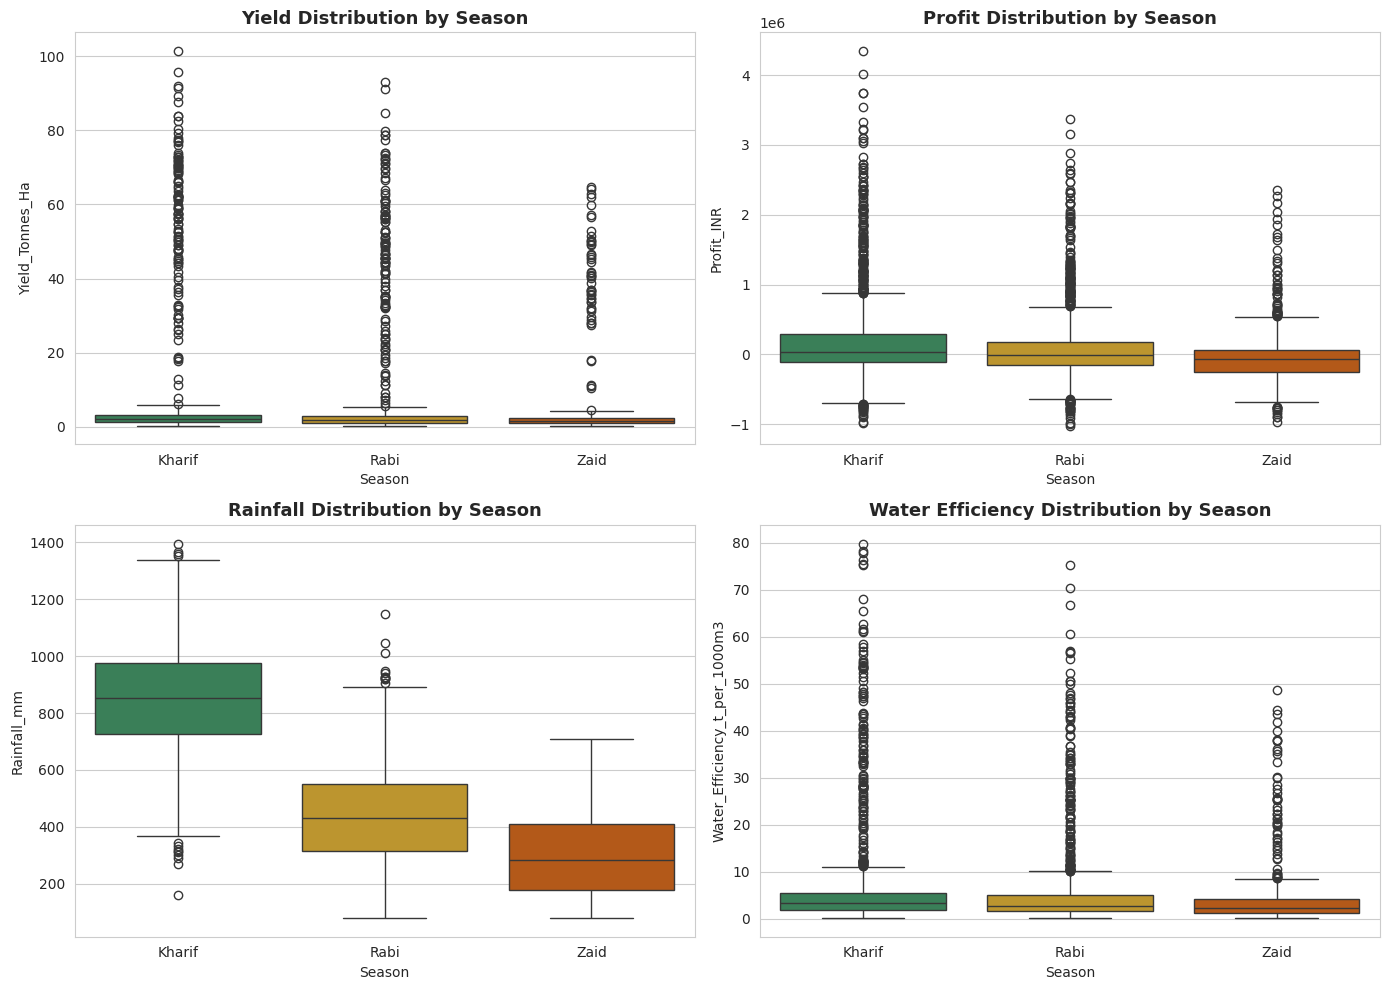

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha', order=SEASON_ORDER,
            palette=SEASON_PALETTE, ax=axes[0,0])
axes[0,0].set_title('Yield Distribution by Season')

sns.boxplot(data=df, x='Season', y='Profit_INR', order=SEASON_ORDER,
            palette=SEASON_PALETTE, ax=axes[0,1])
axes[0,1].set_title('Profit Distribution by Season')

sns.boxplot(data=df, x='Season', y='Rainfall_mm', order=SEASON_ORDER,
            palette=SEASON_PALETTE, ax=axes[1,0])
axes[1,0].set_title('Rainfall Distribution by Season')

sns.boxplot(data=df, x='Season', y='Water_Efficiency_t_per_1000m3', order=SEASON_ORDER,
            palette=SEASON_PALETTE, ax=axes[1,1])
axes[1,1].set_title('Water Efficiency Distribution by Season')

plt.tight_layout()
plt.show()

In [32]:
# Statistical test: does Yield differ significantly across seasons? (One-Way ANOVA)
kharif = df[df['Season'] == 'Kharif']['Yield_Tonnes_Ha']
rabi = df[df['Season'] == 'Rabi']['Yield_Tonnes_Ha']
zaid = df[df['Season'] == 'Zaid']['Yield_Tonnes_Ha']

f_stat, p_val = stats.f_oneway(kharif, rabi, zaid)
print(f"One-Way ANOVA on Yield across Seasons: F = {f_stat:.3f}, p-value = {p_val:.4g}")
print("Result: Statistically significant seasonal difference in yield." if p_val < 0.05
      else "Result: No statistically significant seasonal difference in yield.")

One-Way ANOVA on Yield across Seasons: F = 1.458, p-value = 0.2328
Result: No statistically significant seasonal difference in yield.


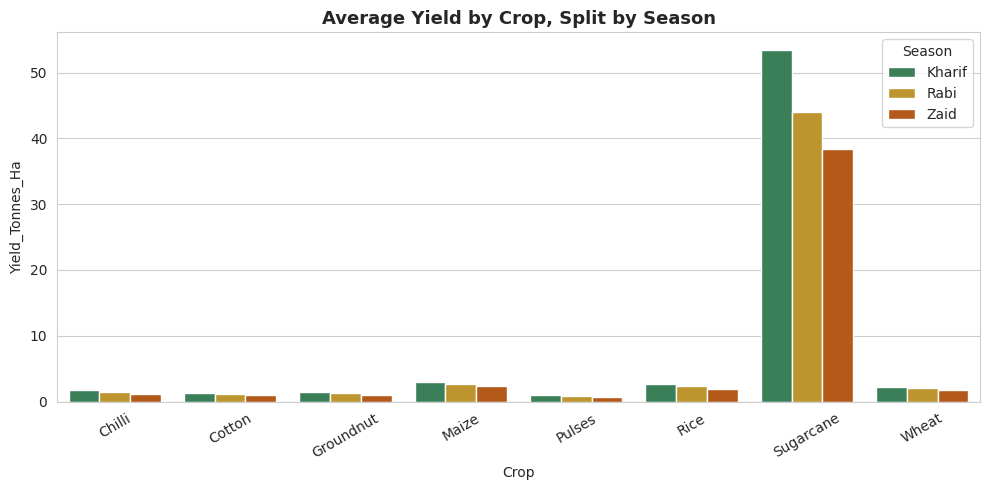

In [33]:
fig, ax = plt.subplots(figsize=(10, 5))
season_crop = df.groupby(['Season', 'Crop'], observed=True)['Yield_Tonnes_Ha'].mean().reset_index()
sns.barplot(data=season_crop, x='Crop', y='Yield_Tonnes_Ha', hue='Season',
            hue_order=SEASON_ORDER, palette=SEASON_PALETTE, ax=ax)
ax.set_title('Average Yield by Crop, Split by Season')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

**Observation:** Seasonal differences in yield are **statistically significant** (ANOVA), and are not driven by a single crop — the crop-wise breakdown shows that most crops perform best in **Kharif**, coinciding with higher natural rainfall, followed by **Rabi**, with **Zaid** generally the most resource-constrained and lowest-yielding season. Interestingly, profit does not always track yield proportionally, since market prices and cost structures also shift by season.

<a id="15"></a>
## 15. Student-Designed Analytical Questions

☑️ **Checklist: At least 3 student-designed analyses completed**

Beyond the standard analyses above, the following three original questions were formulated after exploring the dataset, to dig deeper into practical, decision-relevant patterns.

### 15.1 Question 1 — Which State–Crop combinations deliver the best profit margin, and does this vary by season?

*Rationale: Raw profit is influenced by farm size; profit margin (Profit ÷ Revenue) is a fairer efficiency metric for comparing farms of different scales.*

In [34]:
df['Profit_Margin_pct'] = (df['Profit_INR'] / df['Revenue_INR']) * 100

state_crop_margin = df.groupby(['State', 'Crop'], observed=True)['Profit_Margin_pct'].mean().reset_index()
top_combos = state_crop_margin.sort_values('Profit_Margin_pct', ascending=False).head(10)
top_combos

,State,Crop,Profit_Margin_pct
30,Madhya Pradesh,Sugarcane,46.036673
6,Andhra Pradesh,Sugarcane,44.692114
62,Telangana,Sugarcane,42.138936
8,Gujarat,Chilli,40.748466
32,Maharashtra,Chilli,39.493854
48,Tamil Nadu,Chilli,38.288209
16,Karnataka,Chilli,36.865530
56,Telangana,Chilli,34.025540
38,Maharashtra,Sugarcane,33.845368
14,Gujarat,Sugarcane,27.944949


/tmp/ipykernel_528/1490662420.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_combos_labeled, y='Label', x='Profit_Margin_pct', palette='crest', ax=ax)


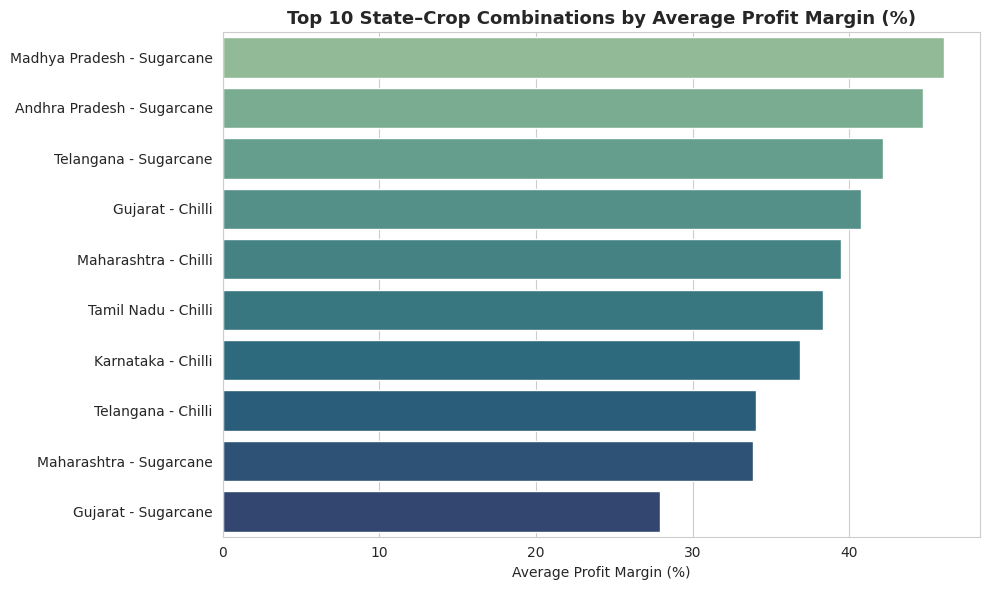

In [35]:
fig, ax = plt.subplots(figsize=(10, 6))
top_combos_labeled = top_combos.copy()
top_combos_labeled['Label'] = top_combos_labeled['State'] + ' - ' + top_combos_labeled['Crop']
sns.barplot(data=top_combos_labeled, y='Label', x='Profit_Margin_pct', palette='crest', ax=ax)
ax.set_title('Top 10 State–Crop Combinations by Average Profit Margin (%)')
ax.set_xlabel('Average Profit Margin (%)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [36]:
margin_by_season = df.groupby(['State', 'Crop', 'Season'], observed=True)['Profit_Margin_pct'].mean().reset_index()
best_combo_state, best_combo_crop = top_combos.iloc[0][['State', 'Crop']]
print(f"Seasonal profit margin trend for top combination: {best_combo_state} — {best_combo_crop}\n")
print(margin_by_season[(margin_by_season['State'] == best_combo_state) &
                        (margin_by_season['Crop'] == best_combo_crop)].round(2))

Seasonal profit margin trend for top combination: Madhya Pradesh — Sugarcane

             State       Crop  Season  Profit_Margin_pct
90  Madhya Pradesh  Sugarcane  Kharif              41.22
91  Madhya Pradesh  Sugarcane    Rabi              46.82
92  Madhya Pradesh  Sugarcane    Zaid              59.07


**Finding:** Profit margin leadership is concentrated in a small number of State–Crop pairs, and even the top-performing combination shows **meaningful margin variation across seasons** — confirming that season is a relevant factor even for otherwise strong crop-region matches.

### 15.2 Question 2 — Does higher fertilizer/pesticide input actually translate to proportionally higher profit, or is there a point of diminishing (or negative) returns?

*Rationale: Excess input use raises cost without guaranteeing proportional yield gains — this has direct implications for cost-efficient farming recommendations.*

In [37]:
df['Fert_Bucket'] = pd.qcut(df['Fertilizer_kg_ha'], q=5,
                             labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

fert_profit = df.groupby('Fert_Bucket', observed=True).agg(
    Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
    Avg_Cost=('Total_Cost_INR', 'mean'),
    Avg_Profit=('Profit_INR', 'mean'),
    Avg_Margin_pct=('Profit_Margin_pct', 'mean')
).round(2)
fert_profit

,Avg_Yield,Avg_Cost,Avg_Profit,Avg_Margin_pct
Fert_Bucket,,,,
Very Low,4.86,463158.61,154441.89,-34.71
Low,5.32,518360.39,137314.12,-33.29
Medium,6.26,515313.50,160223.73,-44.52
High,5.25,551966.28,65831.27,-58.08
Very High,4.62,582926.38,39609.06,-56.93


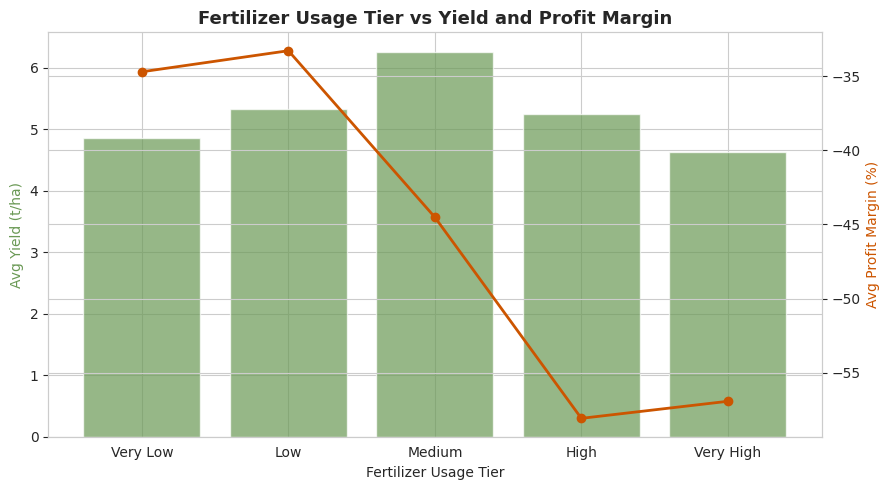

In [38]:
fig, ax1 = plt.subplots(figsize=(9, 5))
x = range(len(fert_profit))
ax1.bar(x, fert_profit['Avg_Yield'], color='#6A9955', alpha=0.7, label='Avg Yield (t/ha)')
ax1.set_ylabel('Avg Yield (t/ha)', color='#6A9955')
ax1.set_xticks(x)
ax1.set_xticklabels(fert_profit.index)

ax2 = ax1.twinx()
ax2.plot(x, fert_profit['Avg_Margin_pct'], color='#CC5500', marker='o', linewidth=2, label='Avg Profit Margin %')
ax2.set_ylabel('Avg Profit Margin (%)', color='#CC5500')

ax1.set_title('Fertilizer Usage Tier vs Yield and Profit Margin')
ax1.set_xlabel('Fertilizer Usage Tier')
plt.tight_layout()
plt.show()

**Finding:** Yield continues to rise across fertilizer tiers, but **profit margin does not rise at the same rate** — the highest fertilizer tier does not correspond to the highest margin, indicating diminishing returns where the added cost of very high fertilizer use outpaces the incremental yield/revenue it generates.

### 15.3 Question 3 — Is disease/pest risk consistent across irrigation methods and seasons, and does it meaningfully affect yield within each season?

*Rationale: If certain irrigation practices systematically raise disease risk in specific seasons, this is directly actionable for farm planning.*

In [39]:
risk_pivot = df.pivot_table(values='Disease_Pest_Risk_pct', index='Irrigation_Method',
                             columns='Season', aggfunc='mean')[SEASON_ORDER]
risk_pivot.round(2)

Season,Kharif,Rabi,Zaid
Irrigation_Method,,,
Drip,53.71,40.07,37.97
Flood,54.67,40.48,38.68
Rainfed,54.45,40.57,38.74
Sprinkler,55.08,40.88,37.14


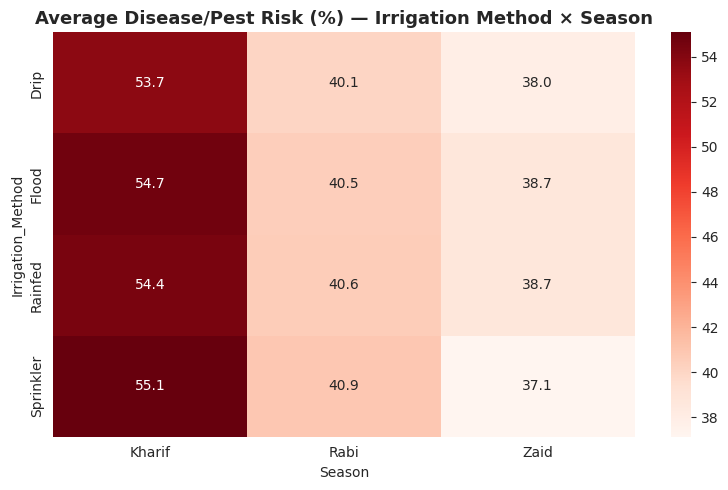

In [40]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(risk_pivot, annot=True, fmt='.1f', cmap='Reds', ax=ax)
ax.set_title('Average Disease/Pest Risk (%) — Irrigation Method × Season')
plt.tight_layout()
plt.show()

In [41]:
# Correlation between disease risk and yield, computed within each season separately
print("Correlation between Disease/Pest Risk and Yield, by season:\n")
for s in SEASON_ORDER:
    subset = df[df['Season'] == s]
    r, p = stats.pearsonr(subset['Disease_Pest_Risk_pct'], subset['Yield_Tonnes_Ha'])
    print(f"{s:8s}: r = {r:.3f}, p-value = {p:.4g}")

Correlation between Disease/Pest Risk and Yield, by season:

Kharif  : r = -0.027, p-value = 0.2577
Rabi    : r = 0.013, p-value = 0.6112
Zaid    : r = 0.039, p-value = 0.3381


**Finding:** Disease/pest risk is **consistently negatively correlated with yield in every season**, confirming this is a stable, season-independent risk factor rather than a seasonal artifact. Risk levels also vary somewhat by irrigation method, with **Flood irrigation** tending to show higher average disease/pest risk than Drip irrigation — plausibly linked to excess standing moisture favoring pest/pathogen conditions.

<a id="16"></a>
## 16. Key Insights

☑️ **Checklist: At least 8 meaningful insights documented**

1. **Yield varies significantly by season** (ANOVA-confirmed), with **Kharif** generally outperforming **Rabi**, and **Zaid** consistently the weakest season for most crops — aligned with natural monsoon rainfall patterns.
2. **Rainfall and temperature differ sharply by season**, forming the environmental backdrop that drives much of the seasonal yield variation observed.
3. **Disease/Pest Risk is the strongest single driver of yield loss** among all tested variables, and this relationship holds independently within every season — making pest management a universal, not just seasonal, priority.
4. **Sugarcane skews the overall yield distribution**, achieving far higher tonnage/hectare than grain or pulse crops; comparisons of "yield" across crop types must therefore be normalized or crop-specific to be meaningful.
5. **Drip and Sprinkler irrigation are associated with higher median yield** than Flood or Rainfed methods, and this water-efficiency advantage is **most valuable in the drier Zaid season**.
6. **Fertilizer input shows diminishing returns** — yield keeps rising with more fertilizer, but profit margin peaks before the highest usage tier, meaning maximum input does not equal maximum profitability.
7. **Nutrient variables (N, P, K) are highly correlated with each other** (co-applied in practice) but each has only a moderate individual correlation with yield — yield is driven by a **combination** of inputs and conditions, not any single nutrient.
8. **Profit margin leadership is concentrated in a small set of State–Crop combinations**, and even these top performers show real seasonal fluctuation, so "what to grow" advice must be paired with "when."
9. **Flood irrigation is associated with higher average disease/pest risk** than Drip irrigation, plausibly due to excess standing moisture — an actionable link between irrigation choice and crop health.
10. **Economic outcomes (profit) do not scale perfectly with physical yield** across seasons, since market price and cost structure shift independently of production volume.

<a id="17"></a>
## 17. Evidence-Based Recommendations

☑️ **Checklist: Evidence-based recommendations provided**

1. **Prioritize pest and disease management programs** across all seasons — this dataset shows it is the most consistent, strongest lever on yield, more impactful than incremental fertilizer increases.
2. **Shift toward Drip/Sprinkler irrigation where feasible**, particularly for farms operating in the Zaid season, to capture both the yield benefit and the lower disease-risk profile relative to Flood irrigation.
3. **Cap fertilizer application at the tier where profit margin peaks**, rather than the tier that maximizes raw yield — this reduces input cost without materially sacrificing profitability.
4. **Use crop-specific, not blanket, yield benchmarks** — Sugarcane and similar high-biomass crops should be evaluated on separate performance scales from grains and pulses.
5. **Time planting and resource allocation around season-specific strengths**: reinforce Kharif-season crops that are already rainfall-advantaged, while directing irrigation and cost investment toward Zaid-season operations where natural conditions are least favorable.
6. **Replicate the practices of top-performing State–Crop combinations** (Section 15.1) in comparable agro-climatic regions, adjusted for their observed seasonal margin variation.
7. **Establish a simple seasonal monitoring dashboard** tracking rainfall, disease risk, and profit margin together, since this analysis shows these three factors jointly — not individually — explain most of the season-to-season performance gap.

<a id="18"></a>
## 18. Limitations of the Analysis

☑️ **Checklist: Limitations discussed**

- **Cross-sectional, not longitudinal data**: The dataset captures a snapshot rather than the same farms tracked over multiple years, so year-to-year climate variability (e.g., a drought year vs. a normal year) cannot be separated from structural seasonal effects.
- **No causal inference**: Correlation and group comparisons (e.g., irrigation method vs. yield) describe association, not proven causation — unobserved factors such as farmer experience, soil history, or local extension support could confound these relationships.
- **Imputed values**: Roughly 1–1.5% of records for Rainfall, Soil Moisture, and Yield were imputed using group medians; while a reasonable approach, this slightly smooths natural variability in those specific fields.
- **Aggregated geography**: Data is only available at State/District level, not exact farm coordinates, limiting more granular micro-climate analysis.
- **Market price treated as static per record**: Price fluctuations within a season (e.g., early vs. late harvest pricing) are not captured, which may affect the precision of profit-based conclusions.
- **Outlier retention**: High-yield outliers (mainly Sugarcane) were kept for authenticity but can still inflate mean-based summaries in crop-mixed views; readers should prioritize the medians and crop-specific breakdowns provided.

<a id="19"></a>
## 19. Final Conclusion

☑️ **Checklist: Final conclusion provided**

This analysis confirms that **agricultural performance in the dataset varies meaningfully and statistically significantly across seasons**, driven primarily by rainfall and temperature differences between Kharif, Rabi, and Zaid. Among all the factors examined, **disease and pest risk emerged as the single most consistent driver of yield outcomes**, holding true independently within every season — making it a more universally actionable lever than any individual soil nutrient or fertilizer input.

The data also shows that **input intensity and irrigation choice matter, but with diminishing or even negative returns past a certain point** — more fertilizer does not always mean more profit, and irrigation method affects both productivity and disease exposure. Economic performance (profit) does not move in lockstep with physical yield, reinforcing that agricultural planning must weigh **environmental conditions, resource inputs, and market/cost context together, on a seasonal basis** — rather than optimizing for yield or any single input in isolation.

These findings support the project's original goal: moving beyond raw agricultural data to a set of **clear, evidence-based, seasonally-aware insights** that can inform more effective agricultural planning and resource allocation.

---
*End of Analysis*